## Train the PF-Controller Neural Network

For each performance metric, train the corresponding particle-filter (PF) controller neural network.

In [1]:
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt

from experiment_config import (
    SEED,
    DegModel,
    dataset_paths,
)
from src.helpers.seed import set_global_seed
from src.models.networks.pf_mlp import ParticleFilterMLP
from src.training.pfnet_hparams import PFNET_ARGS
from src.training.pfnet_training import train_pf_controller_cv

## Task

In [2]:
DATA_NAME = "DS05"
perform_name = "T48"
ARGS_ID = 5

## Hyper-Parameters

In [3]:
args = PFNET_ARGS[ARGS_ID]

net_args = args["NETWORK"]

if net_args is None:
    raise SystemExit(
        "This ARGS_ID is a no-network baseline (NETWORK=None): there is no "
        "network to train. Use it only in the test/ablation notebooks."
    )
pf_args = args["PARTICLE_FILTER"]
train_args = args["TRAINING"]
eval_args = args["EVALUATION"]

In [4]:
set_global_seed(SEED)

ESTIMATION_DIR, DEGR_MODEL_DIR = dataset_paths(
    DATA_NAME, fields=["estimation", "degr_model"]
)

PFNET_ARGS_DIR = DEGR_MODEL_DIR / f"net_arg{ARGS_ID}"
PERFORM_DIR = PFNET_ARGS_DIR / perform_name

checkpoint_best_path = PERFORM_DIR / "checkpoint_best.pt"
checkpoint_last_path = PERFORM_DIR / "checkpoint_last.pt"
checkpoint_best_path.parent.mkdir(parents=True, exist_ok=True)

## Import training data

In [5]:
hi_df = pd.read_csv(ESTIMATION_DIR / "data_dev.csv")
units = hi_df["unit"].astype(int).unique().tolist()
units

[1, 2, 3, 4, 5, 6]

### Extract degradation onset

In [6]:
onsets = {
    unit: hi_df[(hi_df["unit"] == unit) & (hi_df["hs"] == 0)]["cycle"].values[0]
    for unit in units
}
del hi_df["hs"]

In [7]:
perform_names = [col for col in hi_df.columns if col not in ["unit", "cycle"]]

performs = {
    name: {unit: hi_df[hi_df["unit"] == unit][name].values for unit in units}
    for name in perform_names
}

init_ss = {
    name: {unit: perform[unit].max() for unit in units}
    for name, perform in performs.items()
}
time = {unit: hi_df[hi_df["unit"] == unit]["cycle"].values for unit in units}

## Create component (base) models

In [8]:
dev_data = {}
dev_eol = {}
for unit in units:
    t = time[unit]
    s = performs[perform_name][unit]
    dev_data[unit] = torch.tensor(np.stack([t, s], axis=1), dtype=torch.float32)
    dev_eol[unit] = torch.tensor(t[-1], dtype=torch.float32)


In [9]:
dev_degmodels = {}
for unit in performs[perform_name]:
    best_model = DegModel(onset=onsets[unit], init_s=init_ss[perform_name][unit])
    best_model.load_state_dict(
        torch.load(
            DEGR_MODEL_DIR / "states" / perform_name / f"unit_{unit}" / "best_model.pt"
        )
    )
    dev_degmodels[unit] = best_model

## Train Particle Filter controller Net

In [10]:
from src.models.networks.pf_mlp import build_activation

net = ParticleFilterMLP(
    state_dim=DegModel.state_dim(),
    hidden_dims=list(net_args["HIDDEN_DIMS"]),
    activation=build_activation(net_args),
    dropout_p=float(net_args["DROPOUT"]),
)

optimizer = torch.optim.Adam(net.parameters(), float(train_args["LR"]))
optimizer.zero_grad()

In [11]:
best_score = float("inf")
train_epoch_losses = []
eval_epoch_losses = []
scores = []
start_epoch = 0

if checkpoint_last_path.exists():
    ckpt = torch.load(checkpoint_last_path, weights_only=False)

    net.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    start_epoch = ckpt["epoch"] + 1
    best_score = ckpt["best_score"]
    scores = ckpt.get("scores", [])
    train_epoch_losses = ckpt.get("train_losses", [])
    eval_epoch_losses = ckpt.get("eval_losses", [])

    torch.random.set_rng_state(ckpt["rng_torch"])
    np.random.set_state(ckpt["rng_numpy"])

    print(f"✓ Resumed from epoch {start_epoch}, best_score={best_score:.3f}")

In [ ]:
train_state = train_pf_controller_cv(
    net=net,
    optimizer=optimizer,
    units=units,
    dev_data=dev_data,
    dev_degmodels=dev_degmodels,
    n_particles=int(pf_args["N_PARTICLES"]),
    max_life=int(pf_args["MAX_LIFE"]),
    loss_tail_steps=int(train_args["LOSS_TAIL_STEPS"]),
    n_epochs=int(train_args["N_EPOCHS"]),
    checkpoint_best_path=checkpoint_best_path,
    checkpoint_last_path=checkpoint_last_path,
    start_epoch=start_epoch,
    best_score=best_score,
    scores=scores,
    train_epoch_losses=train_epoch_losses,
    eval_epoch_losses=eval_epoch_losses,
    seed=SEED,
    eval_repetitions=int(eval_args["REPETITIONS"]),
    eval_seed_stride=int(eval_args["SEED_STRIDE"]),
    eval_initial_interval_epochs=int(eval_args["INITIAL_INTERVAL_EPOCHS"]),
    eval_final_interval_epochs=int(eval_args["FINAL_INTERVAL_EPOCHS"]),
    match_train_eval_prior=bool(train_args.get("MATCH_TRAIN_EVAL_PRIOR", False)),
    verbose=True,
)

best_score = train_state["best_score"]
scores = train_state["scores"]
train_epoch_losses = train_state["train_epoch_losses"]
eval_epoch_losses = train_state["eval_epoch_losses"]
epoch = train_state["epoch"]
best_checkpoint = train_state["best_checkpoint"]

if best_checkpoint is None and checkpoint_best_path.exists():
    best_checkpoint = torch.load(checkpoint_best_path, weights_only=False)

[Epoch 000] train=9.660 | eval=16.269 | score=16.269 (eval_every~12)
  + saved (score=16.269)
[Epoch 001] train=7.613 | eval=skipped (eval_every~12)
[Epoch 002] train=6.134 | eval=skipped (eval_every~12)
[Epoch 003] train=5.310 | eval=skipped (eval_every~12)
[Epoch 004] train=4.843 | eval=skipped (eval_every~12)
[Epoch 005] train=4.470 | eval=skipped (eval_every~12)
[Epoch 006] train=4.254 | eval=skipped (eval_every~12)
[Epoch 007] train=4.093 | eval=skipped (eval_every~12)
[Epoch 008] train=4.016 | eval=skipped (eval_every~12)
[Epoch 009] train=3.956 | eval=skipped (eval_every~12)
[Epoch 010] train=3.889 | eval=skipped (eval_every~12)
[Epoch 011] train=3.855 | eval=skipped (eval_every~12)
[Epoch 012] train=3.805 | eval=3.718 | score=3.718 (eval_every~12)
  + saved (score=3.718)
[Epoch 013] train=3.780 | eval=skipped (eval_every~12)
[Epoch 014] train=3.762 | eval=skipped (eval_every~11)
[Epoch 015] train=3.743 | eval=skipped (eval_every~11)
[Epoch 016] train=3.698 | eval=skipped (eval_

## Plot

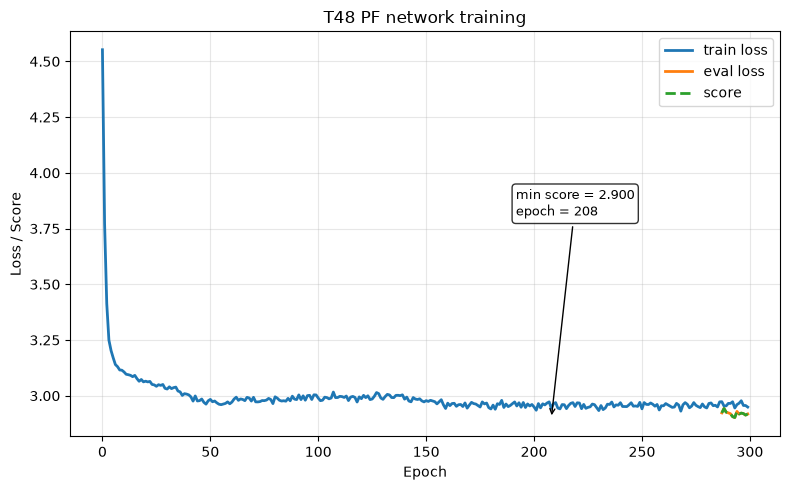

✓ Plot saved to /lustre/diazgonz/deep-performance-rul/experiments/DS03/opcond_q0.001-0.999_corr0.6_range0.6/estimation_thr0.2/gamma/net_arg5/T48/net_training_loss.png
✓ Best epoch: 208 (score=2.8997)


In [ ]:
train_loss_arr = np.array(train_epoch_losses)
eval_loss_arr = np.array(eval_epoch_losses)
score_arr = np.array(scores)
best_epoch = best_checkpoint["epoch"]

epochs = np.arange(len(train_loss_arr))

# best epoch based on score

best_score = score_arr[best_epoch]
best_eval_loss = eval_loss_arr[best_epoch]

plt.figure(figsize=(8, 5))

# Main curves
plt.plot(epochs, train_loss_arr, linewidth=2, label="train loss")
plt.plot(epochs, eval_loss_arr, linewidth=2, label="eval loss")
plt.plot(epochs, score_arr, linewidth=2, linestyle="--", label="score")

ymin, ymax = plt.ylim()
yrange = ymax - ymin

xmin, xmax = plt.xlim()
xrange = xmax - xmin

y_offset = 0.5 * yrange
x_offset = -0.05 * xrange

# Annotation of best score
plt.annotate(
    f"min score = {best_score:.3f}\nepoch = {best_epoch}",
    xy=(best_epoch, best_score),
    xytext=(best_epoch + x_offset, best_score + y_offset),
    textcoords="data",
    arrowprops={"arrowstyle": "->", "linewidth": 1},
    fontsize=9,
    bbox={"boxstyle": "round,pad=0.3", "fc": "white", "alpha": 0.8},
)

plt.xlabel("Epoch")
plt.ylabel("Loss / Score")
plt.title(f"{perform_name} PF network training")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save figure
fig_path = PERFORM_DIR / "net_training_loss.png"
plt.savefig(fig_path, dpi=300)

# Save raw arrays
np.save(PERFORM_DIR / "net_training.npy", train_loss_arr)
np.save(PERFORM_DIR / "net_eval.npy", eval_loss_arr)
np.save(PERFORM_DIR / "net_score.npy", score_arr)
np.save(PERFORM_DIR / "net_bestepoch.npy", best_epoch)

plt.show()

print(f"✓ Plot saved to {fig_path}")
print(f"✓ Best epoch: {best_epoch} (score={best_score:.4f})")